# p06_ppo: 人工データ適応ノートブック

このノートブックは `refs/ppo.ipynb` をベースに、以下の要件へ適応します。

- 1年(252営業日)の人工データをブロックブートストラップで生成
- 学習1000シナリオ / テスト1000シナリオ（既定は軽量デモ）
- 資産は `LIT, SOCL, RNRG, MILN, AGNG, BOTZ, FINX, SNSR, PAVE, DRIV`
- 週次リバランス: 金曜決定 -> 翌営業日適用
- 比較: PPO / ONS / EG / FTRL（出力スキーマ互換）


In [1]:
import warnings
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.set_printoptions(precision=6, suppress=True)
pd.options.display.float_format = "{:.6f}".format

THEME_PATH = "data/theme_etf.csv"
VIX_PATH = "data/vix_daily.csv"

FIXED_TOP10 = [
    "LIT", "SOCL", "RNRG", "MILN", "AGNG",
    "BOTZ", "FINX", "SNSR", "PAVE", "DRIV",
]

print("環境初期化完了")


環境初期化完了


In [2]:
# ============================================================
# 0) Utilities
# ============================================================
def price_relatives_from_prices(prices: pd.DataFrame) -> pd.DataFrame:
    x = prices / prices.shift(1)
    return x.dropna()


def project_to_simplex(v: np.ndarray, z: float = 1.0) -> np.ndarray:
    v = np.asarray(v, dtype=float).ravel()
    n = v.size
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - z
    ind = np.arange(1, n + 1)
    cond = u - cssv / ind > 0
    if not np.any(cond):
        w = np.zeros_like(v)
        w[np.argmax(v)] = z
        return w
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / rho
    w = np.maximum(v - theta, 0.0)
    s = w.sum()
    if s <= 0:
        return np.ones_like(v) / n
    return w * (z / s)


def safe_softmax(a: np.ndarray, temp: float = 1.0) -> np.ndarray:
    a = np.asarray(a, dtype=float).ravel()
    a = a / max(temp, 1e-12)
    a = a - np.max(a)
    ea = np.exp(a)
    return ea / max(ea.sum(), 1e-12)


def annualize_stats(ret_s: pd.Series, periods_per_year: int = 252) -> dict:
    mu = ret_s.mean()
    vol = ret_s.std(ddof=0)
    ann_ret = (1.0 + mu) ** periods_per_year - 1.0
    ann_vol = vol * np.sqrt(periods_per_year)
    sharpe = (mu / (vol + 1e-12)) * np.sqrt(periods_per_year)
    return {
        "ann_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
    }


def max_drawdown(nav: pd.Series) -> float:
    peak = nav.cummax()
    dd = nav / peak - 1.0
    return float(dd.min())


def realized_vol(ret_s: pd.Series, lookback: int = 20, periods_per_year: int = 252) -> pd.Series:
    return ret_s.rolling(lookback).std(ddof=0) * np.sqrt(periods_per_year)


def turnover_l1(w_new: np.ndarray, w_old: np.ndarray) -> float:
    return float(np.sum(np.abs(w_new - w_old)))


def align_series_to_index(s: pd.Series, idx: pd.Index, name: str = "VIX") -> pd.Series:
    s = s.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s = s.reindex(idx).ffill().bfill()
    s.name = name
    return s


# ============================================================
# 1) Side-information signals (no lookahead)
# ============================================================
def make_side_info_signals(prices: pd.DataFrame, mom_window: int = 20, vol_window: int = 20, clip: float = 3.0) -> pd.DataFrame:
    logp = np.log(np.maximum(prices, 1e-12))
    mom = logp - logp.shift(mom_window)
    lr = logp.diff()
    vol = lr.rolling(vol_window).std(ddof=0)

    def cs_zscore(df: pd.DataFrame) -> pd.DataFrame:
        mu = df.mean(axis=1)
        sd = df.std(axis=1, ddof=0).replace(0.0, np.nan)
        return (df.sub(mu, axis=0)).div(sd, axis=0)

    mom_z = cs_zscore(mom).clip(-clip, clip)
    vol_z = cs_zscore(vol).clip(-clip, clip)
    score = (mom_z - vol_z)
    return score


def prior_from_signal(signal_row: np.ndarray, temp: float = 1.0) -> np.ndarray:
    return safe_softmax(signal_row, temp=temp)


# ============================================================
# 2) Local data loaders
# ============================================================
def load_local_market_data(
    theme_path: str,
    vix_path: str,
    lookback_years: int = 5,
    top_n: int = 10,
) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    """
    直近5年・上位銘柄の価格とVIXをローカルCSVから読み込む。
    top_n=10 の場合は計画で固定したティッカー順を優先する。
    """
    theme_raw = pd.read_csv(theme_path, header=[0, 1], index_col=0)
    if "Adj Close" not in theme_raw.columns.get_level_values(0):
        raise ValueError("theme_etf.csv に 'Adj Close' が見つかりません。")

    prices_all = theme_raw["Adj Close"].copy()
    prices_all.index = pd.to_datetime(prices_all.index)
    prices_all = prices_all.sort_index()

    end = prices_all.index.max()
    start = end - pd.DateOffset(years=lookback_years)
    prices_window = prices_all.loc[start:end]

    if top_n == 10:
        missing = [t for t in FIXED_TOP10 if t not in prices_window.columns]
        if missing:
            raise ValueError(f"固定10銘柄が不足しています: {missing}")
        tickers = FIXED_TOP10.copy()
    else:
        counts = prices_window.notna().sum().sort_values(ascending=False)
        tickers = counts.index[:top_n].tolist()

    prices_panel = prices_window[tickers].dropna(how="any")
    if prices_panel.empty:
        raise ValueError("価格パネルが空です。入力データを確認してください。")

    vix_raw = pd.read_csv(vix_path)
    if {"Date", "Close"}.issubset(vix_raw.columns):
        vix_s = vix_raw[["Date", "Close"]].copy()
        vix_s["Date"] = pd.to_datetime(vix_s["Date"])
        vix_s = vix_s.set_index("Date")["Close"].astype(float).sort_index()
    else:
        raise ValueError("vix_daily.csv は Date,Close 列を持つ必要があります。")

    vix_aligned = align_series_to_index(vix_s, prices_panel.index, name="VIX")
    return prices_panel, vix_aligned, tickers


# ============================================================
# 3) Synthetic scenario generation
# ============================================================
def generate_block_bootstrap_scenarios(
    prices_df: pd.DataFrame,
    vix_s: pd.Series,
    n_scenarios: int,
    horizon: int = 252,
    block_len: int = 20,
    seed: int = 0,
) -> dict:
    """
    価格相対(x_t)をブロックブートストラップで生成。
    VIXも同じサンプルインデックスで同時に生成する。
    """
    x = price_relatives_from_prices(prices_df)
    if len(x) <= block_len:
        raise ValueError("履歴長が block_len 以下です。")

    vix_x = align_series_to_index(vix_s, x.index, name="VIX")

    R = x.to_numpy(dtype=float)
    V = vix_x.to_numpy(dtype=float)
    n_hist, d = R.shape

    rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(horizon / block_len))
    max_start = n_hist - block_len
    if max_start < 0:
        raise ValueError("max_start < 0 です。block_len を小さくしてください。")

    scen_r = np.zeros((n_scenarios, horizon, d), dtype=float)
    scen_v = np.zeros((n_scenarios, horizon), dtype=float)
    scen_idx = []

    base = pd.Timestamp("2000-01-03")
    for sid in range(n_scenarios):
        starts = rng.integers(0, max_start + 1, size=n_blocks)
        cur = 0
        for s in starts:
            take = min(block_len, horizon - cur)
            scen_r[sid, cur : cur + take] = R[s : s + take]
            scen_v[sid, cur : cur + take] = V[s : s + take]
            cur += take
            if cur >= horizon:
                break

        idx_ret = pd.bdate_range(base + pd.offsets.BDay(sid * (horizon + 5) + 1), periods=horizon)
        scen_idx.append(idx_ret)

    return {
        "returns": scen_r,
        "vix": scen_v,
        "indices": scen_idx,
        "tickers": list(prices_df.columns),
        "n_scenarios": int(n_scenarios),
        "horizon": int(horizon),
        "block_len": int(block_len),
        "seed": int(seed),
    }


def build_synthetic_price_panel(scenarios_dict: dict, scenario_id: int) -> tuple[pd.DataFrame, pd.Series]:
    """
    1シナリオを prices_df / vix_s として復元する。
    prices_df は horizon+1 行 (先頭は初期値) を返す。
    """
    returns = scenarios_dict["returns"][scenario_id]
    vix_r = scenarios_dict["vix"][scenario_id]
    idx_ret = scenarios_dict["indices"][scenario_id]
    tickers = scenarios_dict["tickers"]

    d = returns.shape[1]
    base_price = np.full(d, 100.0, dtype=float)
    path = np.vstack([base_price, base_price * np.cumprod(returns, axis=0)])

    idx0 = idx_ret[0] - pd.offsets.BDay(1)
    idx_prices = pd.DatetimeIndex([idx0]).append(idx_ret)

    prices_df = pd.DataFrame(path, index=idx_prices, columns=tickers)
    vix_path = np.concatenate([[vix_r[0]], vix_r])
    vix_s = pd.Series(vix_path, index=idx_prices, name="VIX")
    return prices_df, vix_s


def build_concatenated_training_panel(
    scenarios_dict: dict,
    scenario_ids: list[int] | None = None,
) -> tuple[pd.DataFrame, pd.Series, list[int], pd.DataFrame]:
    """
    学習シナリオを1本の系列へ連結し、境界位置と境界非リークの signal を返す。
    returns の境界は scenario_boundaries (x-index基準) で管理する。
    """
    if scenario_ids is None:
        scenario_ids = list(range(scenarios_dict["n_scenarios"]))

    ret_arr = scenarios_dict["returns"][scenario_ids]
    vix_arr = scenarios_dict["vix"][scenario_ids]
    tickers = scenarios_dict["tickers"]

    n_sel, horizon, d = ret_arr.shape
    boundaries = [i * horizon for i in range(n_sel)]

    ret_concat = ret_arr.reshape(n_sel * horizon, d)
    vix_concat = vix_arr.reshape(n_sel * horizon)

    idx_ret = pd.bdate_range("1995-01-03", periods=ret_concat.shape[0])
    idx0 = idx_ret[0] - pd.offsets.BDay(1)
    idx_prices = pd.DatetimeIndex([idx0]).append(idx_ret)

    base_price = np.full(d, 100.0, dtype=float)
    prices_path = np.vstack([base_price, base_price * np.cumprod(ret_concat, axis=0)])
    prices_df = pd.DataFrame(prices_path, index=idx_prices, columns=tickers)

    vix_path = np.concatenate([[vix_concat[0]], vix_concat])
    vix_s = pd.Series(vix_path, index=idx_prices, name="VIX")

    # 境界ごとに signal を作り、連結時のリークを防ぐ
    signal_parts = []
    for i in range(n_sel):
        r_i = ret_arr[i]
        px_i = np.vstack([base_price, base_price * np.cumprod(r_i, axis=0)])
        idx_ret_i = idx_ret[i * horizon : (i + 1) * horizon]
        idx_prices_i = pd.DatetimeIndex([idx_ret_i[0] - pd.offsets.BDay(1)]).append(idx_ret_i)
        prices_i = pd.DataFrame(px_i, index=idx_prices_i, columns=tickers)

        sig_i = make_side_info_signals(prices_i).reindex(idx_ret_i).fillna(0.0)
        sig_i.index = idx_ret_i
        signal_parts.append(sig_i)

    signal_concat = pd.concat(signal_parts, axis=0)
    return prices_df, vix_s, boundaries, signal_concat


# ============================================================
# 4) Rebalance schedule helpers
# ============================================================
def build_rebalance_schedule(
    index: pd.Index,
    mode: str = "daily",
    decision_weekday: int = 4,
    execution_lag: int = 1,
) -> np.ndarray:
    """
    戻り値は「適用日マスク」。
    - daily: 毎営業日決定を execution_lag 日後に適用
    - weekly: decision_weekday 決定を execution_lag 日後に適用
    """
    idx = pd.DatetimeIndex(index)
    T = len(idx)

    if execution_lag < 0:
        raise ValueError("execution_lag は 0 以上で指定してください。")

    mode = str(mode).lower()
    if mode == "daily":
        decision = np.ones(T, dtype=bool)
    elif mode == "weekly":
        decision = (idx.weekday == int(decision_weekday))
    else:
        raise ValueError("mode は 'daily' または 'weekly' を指定してください。")

    if execution_lag == 0:
        apply_mask = decision.copy()
    else:
        apply_mask = np.roll(decision, int(execution_lag))
        apply_mask[: int(execution_lag)] = False

    return apply_mask.astype(bool)


def build_weekly_execution_schedule(
    index: pd.Index,
    decision_weekday: int = 4,
    execution_lag: int = 1,
) -> np.ndarray:
    return build_rebalance_schedule(
        index=index,
        mode="weekly",
        decision_weekday=decision_weekday,
        execution_lag=execution_lag,
    )


def infer_decision_mask_from_apply_mask(rebalance_mask: np.ndarray, execution_lag: int = 1) -> np.ndarray:
    rebalance_mask = np.asarray(rebalance_mask, dtype=bool)
    T = len(rebalance_mask)
    decision = np.zeros(T, dtype=bool)
    if execution_lag <= 0:
        decision[:] = rebalance_mask
        return decision
    if T > execution_lag:
        decision[: T - execution_lag] = rebalance_mask[execution_lag:]
    return decision


In [3]:
# ============================================================
# 5) Classical OPS algorithms
# ============================================================
class BaseOPS:
    def __init__(self, eps: float = 1e-12):
        self.eps = float(eps)

    def init_state(self, d: int):
        pass

    def step(self, w: np.ndarray, x_t: np.ndarray) -> np.ndarray:
        raise NotImplementedError


class EGOPS(BaseOPS):
    def __init__(self, eta: float = 0.05, eps: float = 1e-12):
        super().__init__(eps)
        self.eta = float(eta)

    def step(self, w, x_t):
        denom = max(float(w @ x_t), self.eps)
        g = -x_t / denom
        w_new = w * np.exp(-self.eta * g)
        w_new = w_new / max(w_new.sum(), self.eps)
        return w_new


class ONSOPS(BaseOPS):
    def __init__(self, eta: float = 0.3, delta: float = 1.0, clip_grad: float = 1e3, eps: float = 1e-12):
        super().__init__(eps)
        self.eta = float(eta)
        self.delta = float(delta)
        self.clip_grad = float(clip_grad)
        self.invA = None

    def init_state(self, d: int):
        self.invA = (1.0 / self.delta) * np.eye(d)

    def step(self, w, x_t):
        denom = max(float(w @ x_t), self.eps)
        g = -x_t / denom
        g = np.clip(g, -self.clip_grad, self.clip_grad)

        invA_g = self.invA @ g
        denom_sm = 1.0 + float(g @ invA_g)
        self.invA = self.invA - np.outer(invA_g, invA_g) / max(denom_sm, self.eps)

        w_new = w - self.eta * (self.invA @ g)
        return project_to_simplex(w_new)


class FTRLLogBarrierOPS(BaseOPS):
    def __init__(self, eta: float = 0.2, eps: float = 1e-12, nu_tol: float = 1e-12):
        super().__init__(eps)
        self.eta = float(eta)
        self.nu_tol = float(nu_tol)
        self.G = None

    def init_state(self, d: int):
        self.G = np.zeros(d, dtype=float)

    def _solve_nu(self, G: np.ndarray) -> float:
        etaG = self.eta * G
        lo = -np.min(etaG) + 1e-12
        hi = lo + 1.0

        def f(nu):
            denom = etaG + nu
            return np.sum(1.0 / denom) - 1.0

        while f(hi) > 0:
            hi *= 2.0
            if hi > 1e12:
                break

        for _ in range(200):
            mid = 0.5 * (lo + hi)
            val = f(mid)
            if abs(val) < self.nu_tol:
                return mid
            if val > 0:
                lo = mid
            else:
                hi = mid
        return 0.5 * (lo + hi)

    def step(self, w, x_t):
        denom = max(float(w @ x_t), self.eps)
        g = -x_t / denom
        self.G = self.G + g
        nu = self._solve_nu(self.G)

        w_new = 1.0 / (self.eta * self.G + nu)
        w_new = np.maximum(w_new, 0.0)
        w_new = w_new / max(w_new.sum(), self.eps)
        return w_new


def apply_prior_and_vol_targeting(
    w: np.ndarray,
    signal_row: np.ndarray | None,
    side_info_temp: float,
    blend_prior: float,
    cash_asset: bool,
    asset_names: list[str],
    target_vol_ann: float | None,
    vol_lookback: int,
    periods_per_year: int,
    ret_net_hist: list[float],
) -> np.ndarray:
    if signal_row is not None:
        w_prior = prior_from_signal(signal_row, temp=side_info_temp)
        w = project_to_simplex((1.0 - blend_prior) * w + blend_prior * w_prior)

    if cash_asset and (target_vol_ann is not None) and (len(ret_net_hist) >= vol_lookback):
        past = np.asarray(ret_net_hist[-vol_lookback:], dtype=float)
        rv = float(np.std(past, ddof=0) * np.sqrt(periods_per_year))
        rv = max(rv, 1e-12)
        alpha = min(1.0, target_vol_ann / rv)

        cash_idx = asset_names.index("CASH")
        w_cash = np.zeros_like(w)
        w_cash[cash_idx] = 1.0
        w = project_to_simplex(alpha * w + (1.0 - alpha) * w_cash)

    return w


def finalize_outputs(
    x: pd.DataFrame,
    weights: np.ndarray,
    ret_gross: np.ndarray,
    ret_net: np.ndarray,
    turnover: np.ndarray,
    cost: np.ndarray,
    vol_lookback: int,
    periods_per_year: int,
    init_wealth: float,
) -> dict:
    idx = x.index
    w_df = pd.DataFrame(weights, index=idx, columns=x.columns)
    rg_s = pd.Series(ret_gross, index=idx, name="ret_gross")
    rn_s = pd.Series(ret_net, index=idx, name="ret_net")
    to_s = pd.Series(turnover, index=idx, name="turnover")
    c_s = pd.Series(cost, index=idx, name="cost")

    nav_g = (1.0 + rg_s).cumprod() * init_wealth
    nav_n = (1.0 + rn_s).cumprod() * init_wealth
    nav_g.name = "nav_gross"
    nav_n.name = "nav_net"

    rv_n = realized_vol(rn_s, lookback=vol_lookback, periods_per_year=periods_per_year)
    rv_n.name = "realized_vol_ann"

    stats = annualize_stats(rn_s, periods_per_year=periods_per_year)
    summary = {
        **stats,
        "max_drawdown": float(max_drawdown(nav_n)),
        "avg_turnover": float(to_s.mean()),
        "total_cost": float(c_s.sum()),
        "final_nav_net": float(nav_n.iloc[-1]),
        "final_nav_gross": float(nav_g.iloc[-1]),
        "nobs": int(len(rn_s)),
    }

    return {
        "weights": w_df,
        "ret_gross": rg_s,
        "ret_net": rn_s,
        "nav_gross": nav_g,
        "nav_net": nav_n,
        "turnover": to_s,
        "cost": c_s,
        "realized_vol_ann": rv_n,
        "summary": summary,
        "price_relatives": x,
    }


def run_ops_backtest_classical(
    prices: pd.DataFrame,
    algo: str = "ONS",
    cash_asset: bool = True,
    use_side_info: bool = True,
    side_info_temp: float = 1.0,
    blend_prior: float = 0.20,
    target_vol_ann: float | None = 0.10,
    vol_lookback: int = 20,
    periods_per_year: int = 252,
    commission_bps: float = 1.0,
    slippage_bps: float = 1.0,
    algo_params: dict | None = None,
    init_wealth: float = 1.0,
    w0: np.ndarray | None = None,
    rebalance_mask: np.ndarray | None = None,
    execution_lag: int = 1,
):
    prices = prices.dropna().copy()
    x = price_relatives_from_prices(prices)

    signal = None
    if use_side_info:
        signal = make_side_info_signals(prices).reindex(x.index).fillna(0.0)

    if cash_asset:
        x = x.copy()
        x["CASH"] = 1.0
        if signal is not None:
            signal = signal.copy()
            signal["CASH"] = 0.0

    X = x.to_numpy(dtype=float)
    T, d = X.shape
    asset_names = list(x.columns)

    if rebalance_mask is None:
        rebalance_mask = build_rebalance_schedule(x.index, mode="daily", execution_lag=execution_lag)
    rebalance_mask = np.asarray(rebalance_mask, dtype=bool)
    if len(rebalance_mask) != T:
        raise ValueError("rebalance_mask の長さが x と一致しません。")
    decision_mask = infer_decision_mask_from_apply_mask(rebalance_mask, execution_lag=execution_lag)

    algo_params = {} if algo_params is None else dict(algo_params)
    au = algo.upper()
    if au == "ONS":
        model = ONSOPS(**algo_params)
        model.init_state(d)
    elif au == "EG":
        model = EGOPS(**algo_params)
    elif au == "FTRL":
        model = FTRLLogBarrierOPS(**algo_params)
        model.init_state(d)
    else:
        raise ValueError("classical algo must be 'ONS'|'EG'|'FTRL'")

    w_model = np.ones(d) / d if w0 is None else project_to_simplex(w0)
    w_live = w_model.copy()
    pending: dict[int, np.ndarray] = {}

    weights = np.zeros((T, d))
    ret_gross = np.zeros(T)
    ret_net = np.zeros(T)
    turnover = np.zeros(T)
    cost = np.zeros(T)

    tc = (commission_bps + slippage_bps) * 1e-4
    ret_net_hist: list[float] = []

    for t in range(T):
        if t in pending:
            w_live = pending.pop(t)

        xt = X[t]
        rg = float(max(w_live @ xt, 1e-12) - 1.0)

        if t == 0:
            to = 0.0
        else:
            to = turnover_l1(w_live, weights[t - 1])

        c = tc * to
        rn = rg - c

        weights[t] = w_live
        ret_gross[t] = rg
        ret_net[t] = rn
        turnover[t] = to
        cost[t] = c
        ret_net_hist.append(rn)

        w_model = model.step(w_model, xt)

        if decision_mask[t]:
            srow = None
            if signal is not None:
                srow = signal.iloc[t].to_numpy(dtype=float)

            w_candidate = apply_prior_and_vol_targeting(
                w=w_model,
                signal_row=srow,
                side_info_temp=side_info_temp,
                blend_prior=blend_prior,
                cash_asset=cash_asset,
                asset_names=asset_names,
                target_vol_ann=target_vol_ann,
                vol_lookback=vol_lookback,
                periods_per_year=periods_per_year,
                ret_net_hist=ret_net_hist,
            )
            due = t + execution_lag
            if due < T:
                pending[due] = w_candidate

    return finalize_outputs(
        x=x,
        weights=weights,
        ret_gross=ret_gross,
        ret_net=ret_net,
        turnover=turnover,
        cost=cost,
        vol_lookback=vol_lookback,
        periods_per_year=periods_per_year,
        init_wealth=init_wealth,
    )


In [4]:
# ============================================================
# 6) PPO integration (scenario boundary reset + configurable rebalance)
# ============================================================
def build_obs_matrix(
    x: pd.DataFrame,
    lookback: int,
    include_prev_w: bool,
    include_signal: bool,
    signal: pd.DataFrame | None,
    exog: np.ndarray | None = None,
):
    X = x.to_numpy(dtype=float)
    logx = np.log(np.maximum(X, 1e-12))
    T, d = X.shape

    sig_arr = None
    if include_signal and (signal is not None):
        sig_arr = signal.to_numpy(dtype=float)

    k = 0 if exog is None else int(exog.shape[1])

    dim = lookback * d
    if include_prev_w:
        dim += d
    if include_signal and (sig_arr is not None):
        dim += d
    if exog is not None:
        dim += lookback * k

    return X, logx, sig_arr, exog, dim


def simplex_from_action(action: np.ndarray, temp: float = 1.0) -> np.ndarray:
    return safe_softmax(action, temp=temp)


def run_ppo_backtest_same_outputs(
    prices: pd.DataFrame,
    cash_asset: bool = True,
    use_side_info: bool = True,
    side_info_temp: float = 1.0,
    blend_prior: float = 0.20,
    target_vol_ann: float | None = 0.10,
    vol_lookback: int = 20,
    periods_per_year: int = 252,
    commission_bps: float = 1.0,
    slippage_bps: float = 1.0,
    init_wealth: float = 1.0,
    rebalance_mask: np.ndarray | None = None,
    execution_lag: int = 1,
    # PPO-specific
    obs_lookback: int = 20,
    action_temp: float = 1.0,
    include_prev_w: bool = True,
    include_signal_in_obs: bool = True,
    reward_type: str = "log_net",  # "log_net"|"net"|"log_mv_turn"
    # training
    split_date: str | None = None,
    total_timesteps: int = 20_000,
    seed: int = 0,
    ppo_kwargs: dict | None = None,
    pretrained_model=None,
    # VIX exogenous feature
    vix: pd.Series | None = None,
    vix_mode: str = "level",  # "level"|"logret"|"zlevel"
    include_vix_in_obs: bool = True,
    # history in observation
    hist_len: int = 5,
    include_hist_actions: bool = True,
    include_hist_rewards: bool = True,
    include_hist_returns: bool = True,
    include_port_state: bool = True,
    # reward extensions
    mv_lambda: float = 5.0,
    mv_ewm_span: int = 60,
    mv_use_instant: bool = False,
    turn_lambda: float = 0.05,
    turn_mode: str = "l1",  # "l1" or "l2"
    # scenario boundaries for concatenated training
    scenario_boundaries: list[int] | None = None,
    precomputed_signal: pd.DataFrame | None = None,
):
    import gymnasium as gym
    from gymnasium import spaces
    from stable_baselines3 import PPO

    prices = prices.dropna().copy()
    x = price_relatives_from_prices(prices)

    signal = None
    if use_side_info:
        if precomputed_signal is not None:
            signal = precomputed_signal.reindex(x.index).fillna(0.0)
        else:
            signal = make_side_info_signals(prices).reindex(x.index).fillna(0.0)

    if cash_asset:
        x = x.copy()
        x["CASH"] = 1.0
        if signal is not None:
            signal = signal.copy()
            signal["CASH"] = 0.0

    asset_names = list(x.columns)

    vix_feat = None
    if include_vix_in_obs and (vix is not None):
        vix_al = align_series_to_index(vix, x.index, name="VIX")
        vix_al = pd.to_numeric(vix_al, errors="coerce").astype(float).ffill().bfill()

        if vix_mode == "level":
            vix_feat = pd.Series(vix_al.values, index=x.index, name="vix_f")
        elif vix_mode == "logret":
            vv = np.log(np.maximum(vix_al.values, 1e-12))
            dv = pd.Series(vv, index=x.index).diff().fillna(0.0).values
            vix_feat = pd.Series(dv, index=x.index, name="vix_f")
        elif vix_mode == "zlevel":
            m = vix_al.rolling(60).mean()
            s = vix_al.rolling(60).std(ddof=0).replace(0.0, np.nan)
            z = ((vix_al - m) / s).fillna(0.0)
            vix_feat = pd.Series(z.values, index=x.index, name="vix_f")
        else:
            raise ValueError("vix_mode must be 'level'|'logret'|'zlevel'")

    if rebalance_mask is None:
        rebalance_mask = build_rebalance_schedule(x.index, mode="daily", execution_lag=execution_lag)
    rebalance_mask = np.asarray(rebalance_mask, dtype=bool)
    if len(rebalance_mask) != len(x):
        raise ValueError("rebalance_mask length mismatch")

    if scenario_boundaries is None:
        scenario_boundaries = [0]
    scenario_boundaries = sorted(set(int(b) for b in scenario_boundaries if 0 <= int(b) < len(x)))
    if 0 not in scenario_boundaries:
        scenario_boundaries = [0] + scenario_boundaries

    if split_date is None:
        x_tr = x.copy()
        x_te = x.copy()
        sig_tr = None if signal is None else signal.loc[x_tr.index].copy()
        sig_te = None if signal is None else signal.loc[x_te.index].copy()

        ex_tr = None
        ex_te = None
        if vix_feat is not None:
            ex_tr = vix_feat.loc[x_tr.index].to_numpy(dtype=float).reshape(-1, 1)
            ex_te = vix_feat.loc[x_te.index].to_numpy(dtype=float).reshape(-1, 1)

        mask_tr = rebalance_mask.copy()
        mask_te = rebalance_mask.copy()
        bnd_tr = scenario_boundaries.copy()
        bnd_te = [0]
    else:
        split = pd.to_datetime(split_date)
        x_tr = x.loc[:split].copy()
        x_te = x.loc[split:].copy()

        sig_tr = None if signal is None else signal.loc[x_tr.index].copy()
        sig_te = None if signal is None else signal.loc[x_te.index].copy()

        ex_tr = None
        ex_te = None
        if vix_feat is not None:
            ex_tr = vix_feat.loc[x_tr.index].to_numpy(dtype=float).reshape(-1, 1)
            ex_te = vix_feat.loc[x_te.index].to_numpy(dtype=float).reshape(-1, 1)

        mask_tr = rebalance_mask[: len(x_tr)]
        mask_te = rebalance_mask[len(x_tr) : len(x_tr) + len(x_te)]
        bnd_tr = [0]
        bnd_te = [0]

    class PortfolioEnv(gym.Env):
        metadata = {"render_modes": []}

        def __init__(
            self,
            x_df: pd.DataFrame,
            sig_df: pd.DataFrame | None,
            exog: np.ndarray | None,
            rebalance_mask_local: np.ndarray,
            boundaries_local: list[int],
        ):
            super().__init__()
            self.x_df = x_df
            self.sig_df = sig_df

            self.X, self.logx, self.SIG, self.EXOG, self.obs_dim_base = build_obs_matrix(
                x=self.x_df,
                lookback=obs_lookback,
                include_prev_w=include_prev_w,
                include_signal=include_signal_in_obs,
                signal=self.sig_df,
                exog=exog,
            )
            self.T, self.d = self.X.shape

            self.rebalance_mask = np.asarray(rebalance_mask_local, dtype=bool)
            self.decision_mask = infer_decision_mask_from_apply_mask(self.rebalance_mask, execution_lag=execution_lag)

            b = sorted(set(int(v) for v in boundaries_local if 0 <= int(v) < self.T))
            if 0 not in b:
                b = [0] + b
            self.boundaries = b
            self.boundary_set = set(self.boundaries)

            self.start_for_t = np.zeros(self.T, dtype=int)
            for i, s in enumerate(self.boundaries):
                e = self.boundaries[i + 1] if i + 1 < len(self.boundaries) else self.T
                self.start_for_t[s:e] = s

            extra = 0
            self.hist_len = int(hist_len)
            if include_hist_actions:
                extra += self.hist_len * self.d
            if include_hist_rewards:
                extra += self.hist_len
            if include_hist_returns:
                extra += self.hist_len
            if include_port_state:
                extra += 2
            self.obs_dim = int(self.obs_dim_base + extra)

            self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(self.d,), dtype=np.float32)
            self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)

            self.tc = (commission_bps + slippage_bps) * 1e-4
            self.alpha = 2.0 / (float(mv_ewm_span) + 1.0)

            self.t = 0
            self.prepared_t = None
            self.last_boundary_reset = False

        def _reset_portfolio_state(self):
            self.w_live = np.ones(self.d, dtype=float) / self.d
            self.last_exec_w = self.w_live.copy()
            self.ret_net_hist = []
            self.log_wealth = 0.0

            self.hist_actions = np.zeros((self.hist_len, self.d), dtype=np.float32)
            self.hist_rewards = np.zeros((self.hist_len,), dtype=np.float32)
            self.hist_returns = np.zeros((self.hist_len,), dtype=np.float32)

            self.mu_ewm = 0.0
            self.v_ewm = 0.0
            self.var_ewm = 0.0
            self.pending: dict[int, np.ndarray] = {}

        def _prepare_step_state(self):
            if self.prepared_t == self.t:
                return

            self.last_boundary_reset = False
            if self.t in self.boundary_set and self.t != 0:
                self._reset_portfolio_state()
                self.last_boundary_reset = True

            if self.t in self.pending:
                self.w_live = self.pending.pop(self.t)

            self.prepared_t = self.t

        def _pad_window(self, arr: np.ndarray, start: int, end: int, total_len: int) -> np.ndarray:
            win = arr[start:end]
            cur = len(win)
            if cur >= total_len:
                return win[-total_len:]
            pad_shape = (total_len - cur,) + win.shape[1:]
            pad = np.zeros(pad_shape, dtype=win.dtype)
            return np.concatenate([pad, win], axis=0)

        def _port_state_features(self) -> np.ndarray:
            logw = float(self.log_wealth)
            if len(self.ret_net_hist) >= vol_lookback:
                past = np.asarray(self.ret_net_hist[-vol_lookback:], dtype=float)
                rv = float(np.std(past, ddof=0) * np.sqrt(periods_per_year))
            else:
                rv = 0.0
            return np.asarray([logw, rv], dtype=np.float32)

        def _get_obs(self) -> np.ndarray:
            t = self.t
            s0 = self.start_for_t[t]
            start = max(s0, t - obs_lookback)

            win = self._pad_window(self.logx, start, t, obs_lookback)
            obs_parts = [win.reshape(-1)]

            if include_prev_w:
                obs_parts.append(self.w_live.copy())

            if include_signal_in_obs and (self.SIG is not None):
                if (t - 1) >= s0 and (t - 1) >= 0:
                    obs_parts.append(self.SIG[t - 1].copy())
                else:
                    obs_parts.append(np.zeros(self.d, dtype=float))

            if self.EXOG is not None:
                ex_win = self._pad_window(self.EXOG, start, t, obs_lookback)
                obs_parts.append(ex_win.reshape(-1))

            if include_hist_actions:
                obs_parts.append(self.hist_actions.reshape(-1).copy())
            if include_hist_rewards:
                obs_parts.append(self.hist_rewards.copy())
            if include_hist_returns:
                obs_parts.append(self.hist_returns.copy())

            if include_port_state:
                obs_parts.append(self._port_state_features())

            obs = np.concatenate(obs_parts, axis=0).astype(np.float32)
            return obs

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.t = 0
            self.prepared_t = None
            self._reset_portfolio_state()
            self._prepare_step_state()

            obs = self._get_obs()
            assert obs.shape[0] == self.obs_dim, (obs.shape, self.obs_dim)
            return obs, {}

        def _push_history(self, w_exec: np.ndarray, r_scalar: float, rn: float):
            if include_hist_actions:
                self.hist_actions[:-1] = self.hist_actions[1:]
                self.hist_actions[-1] = np.asarray(w_exec, dtype=np.float32)
            if include_hist_rewards:
                self.hist_rewards[:-1] = self.hist_rewards[1:]
                self.hist_rewards[-1] = np.float32(r_scalar)
            if include_hist_returns:
                self.hist_returns[:-1] = self.hist_returns[1:]
                self.hist_returns[-1] = np.float32(rn)

        def _turn_penalty(self, w_exec: np.ndarray, w_prev: np.ndarray) -> float:
            dw = w_exec - w_prev
            if turn_mode == "l2":
                return float(np.sum(dw * dw))
            return float(np.sum(np.abs(dw)))

        def _mv_penalty(self, l: float) -> float:
            var_prev = float(self.var_ewm)
            mu_prev = float(self.mu_ewm)

            if mv_use_instant:
                pen = 0.5 * float(mv_lambda) * (l - mu_prev) ** 2
            else:
                pen = 0.5 * float(mv_lambda) * var_prev

            a = float(self.alpha)
            self.mu_ewm = (1.0 - a) * self.mu_ewm + a * l
            self.v_ewm = (1.0 - a) * self.v_ewm + a * (l * l)
            self.var_ewm = max(self.v_ewm - self.mu_ewm * self.mu_ewm, 1e-12)
            return float(pen)

        def step(self, action):
            self._prepare_step_state()
            t = self.t
            s0 = self.start_for_t[t]

            xt = self.X[t]
            growth = float(max(self.w_live @ xt, 1e-12))
            rg = growth - 1.0

            if t == s0:
                to = 0.0
            else:
                to = turnover_l1(self.w_live, self.last_exec_w)
            c = self.tc * to
            rn = rg - c

            l = float(np.log1p(rn))
            if reward_type == "log_net":
                r = l
            elif reward_type == "net":
                r = float(rn)
            elif reward_type == "log_mv_turn":
                mv_pen = self._mv_penalty(l)
                turn_pen = float(turn_lambda) * self._turn_penalty(self.w_live, self.last_exec_w)
                r = l - mv_pen - turn_pen
            else:
                raise ValueError("reward_type must be 'log_net'|'net'|'log_mv_turn'")

            self.ret_net_hist.append(rn)
            self.log_wealth += l
            self._push_history(w_exec=self.w_live, r_scalar=r, rn=rn)

            if self.decision_mask[t]:
                w_raw = simplex_from_action(np.asarray(action, dtype=float), temp=action_temp)
                srow = None
                if use_side_info and (self.SIG is not None):
                    srow = self.SIG[t].copy()

                w_candidate = apply_prior_and_vol_targeting(
                    w=w_raw,
                    signal_row=srow,
                    side_info_temp=side_info_temp,
                    blend_prior=blend_prior,
                    cash_asset=cash_asset,
                    asset_names=asset_names,
                    target_vol_ann=target_vol_ann,
                    vol_lookback=vol_lookback,
                    periods_per_year=periods_per_year,
                    ret_net_hist=self.ret_net_hist,
                )
                due = t + execution_lag
                if due < self.T:
                    self.pending[due] = w_candidate

            self.last_exec_w = self.w_live.copy()

            info = {
                "w_exec": self.w_live.copy(),
                "ret_gross": rg,
                "ret_net": rn,
                "turnover": to,
                "cost": c,
                "boundary_reset": bool(self.last_boundary_reset),
            }

            self.t += 1
            terminated = (self.t >= self.T)
            truncated = False

            if terminated:
                obs = np.zeros(self.obs_dim, dtype=np.float32)
            else:
                self.prepared_t = None
                self._prepare_step_state()
                obs = self._get_obs()

            return obs, r, terminated, truncated, info

    def rollout_collect(
        model,
        x_df: pd.DataFrame,
        sig_df: pd.DataFrame | None,
        exog: np.ndarray | None,
        rb_mask: np.ndarray,
        boundaries: list[int],
    ) -> dict:
        env = PortfolioEnv(x_df, sig_df, exog, rb_mask, boundaries)
        obs, _ = env.reset(seed=seed)

        weights = []
        ret_gross = []
        ret_net = []
        turnover = []
        cost = []
        breset = []

        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            weights.append(info["w_exec"])
            ret_gross.append(info["ret_gross"])
            ret_net.append(info["ret_net"])
            turnover.append(info["turnover"])
            cost.append(info["cost"])
            breset.append(info["boundary_reset"])
            done = terminated or truncated

        out = finalize_outputs(
            x=x_df,
            weights=np.asarray(weights),
            ret_gross=np.asarray(ret_gross),
            ret_net=np.asarray(ret_net),
            turnover=np.asarray(turnover),
            cost=np.asarray(cost),
            vol_lookback=vol_lookback,
            periods_per_year=periods_per_year,
            init_wealth=init_wealth,
        )
        out["meta"] = {
            "boundary_reset_flags": np.asarray(breset, dtype=bool),
            "boundary_reset_count": int(np.sum(breset)),
        }
        return out

    ppo_kwargs = {} if ppo_kwargs is None else dict(ppo_kwargs)

    if pretrained_model is None:
        env_tr = PortfolioEnv(x_tr, sig_tr, ex_tr, mask_tr, bnd_tr)
        model = PPO(
            policy="MlpPolicy",
            env=env_tr,
            seed=seed,
            verbose=0,
            **ppo_kwargs,
        )
        if int(total_timesteps) > 0:
            model.learn(total_timesteps=int(total_timesteps))
    else:
        model = pretrained_model
        if int(total_timesteps) > 0:
            env_tr = PortfolioEnv(x_tr, sig_tr, ex_tr, mask_tr, bnd_tr)
            model.set_env(env_tr)
            model.learn(total_timesteps=int(total_timesteps), reset_num_timesteps=False)

    out_tr = rollout_collect(model, x_tr, sig_tr, ex_tr, mask_tr, bnd_tr)

    if split_date is None:
        out_te = out_tr
    else:
        out_te = rollout_collect(model, x_te, sig_te, ex_te, mask_te, bnd_te)

    return {
        "model": model,
        "train": out_tr,
        "test": out_te,
    }


# ============================================================
# 7) Multi-scenario evaluation helpers
# ============================================================
def evaluate_on_scenarios(
    method_runner: Callable[[pd.DataFrame, pd.Series, int], dict],
    scenario_set: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for sid in range(scenario_set["n_scenarios"]):
        prices_i, vix_i = build_synthetic_price_panel(scenario_set, sid)
        out = method_runner(prices_i, vix_i, sid)

        row = {"scenario_id": sid}
        row.update(out["summary"])
        rows.append(row)

    per_scenario = pd.DataFrame(rows).set_index("scenario_id").sort_index()

    agg_rows = []
    for c in per_scenario.columns:
        agg_rows.append(
            {
                "metric": c,
                "mean": float(per_scenario[c].mean()),
                "std": float(per_scenario[c].std(ddof=0)),
                "min": float(per_scenario[c].min()),
                "max": float(per_scenario[c].max()),
            }
        )
    aggregate = pd.DataFrame(agg_rows).set_index("metric")
    return per_scenario, aggregate


def summarize_methods(per_method_tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    metrics = [
        "ann_return",
        "ann_vol",
        "sharpe",
        "max_drawdown",
        "avg_turnover",
        "total_cost",
        "final_nav_net",
        "nobs",
    ]
    rows = []
    for name, df in per_method_tables.items():
        row = {m: float(df[m].mean()) for m in metrics if m in df.columns}
        row["name"] = name
        rows.append(row)
    out = pd.DataFrame(rows).set_index("name")
    if "sharpe" in out.columns:
        out = out.sort_values("sharpe", ascending=False)
    return out


# ============================================================
# 8) Validation helpers
# ============================================================
def assert_signal_no_lookahead(prices: pd.DataFrame, seed: int = 7):
    rng = np.random.default_rng(seed)
    sig_a = make_side_info_signals(prices)

    prices_b = prices.copy()
    cut = min(80, len(prices_b) // 3)
    if cut + 1 >= len(prices_b):
        return

    noise = rng.normal(0.0, 0.03, size=prices_b.iloc[cut + 1 :].shape)
    prices_b.iloc[cut + 1 :] = prices_b.iloc[cut + 1 :] * np.exp(noise)
    sig_b = make_side_info_signals(prices_b)

    lhs = sig_a.iloc[: cut + 1].to_numpy(dtype=float)
    rhs = sig_b.iloc[: cut + 1].to_numpy(dtype=float)
    ok = np.allclose(lhs, rhs, equal_nan=True)
    if not ok:
        raise AssertionError("signal に先読み疑いがあります。")


def assert_rebalance_alignment(out: dict, rebalance_mask: np.ndarray):
    w = out["weights"].to_numpy(dtype=float)
    ch = np.zeros(len(w), dtype=bool)
    if len(w) > 1:
        ch[1:] = np.sum(np.abs(w[1:] - w[:-1]), axis=1) > 1e-10
    rb = np.asarray(rebalance_mask, dtype=bool)
    if len(rb) != len(ch):
        raise AssertionError("rebalance_mask 長が一致しません。")
    if not np.all((~ch) | rb):
        bad = np.where(ch & (~rb))[0][:10]
        raise AssertionError(f"リバランス適用に違反する日があります: {bad}")


def assert_weekly_alignment(out: dict, rebalance_mask: np.ndarray):
    # 互換性維持ラッパー
    assert_rebalance_alignment(out, rebalance_mask)


def assert_schema_compat(out: dict):
    required = {
        "weights",
        "ret_gross",
        "ret_net",
        "nav_gross",
        "nav_net",
        "turnover",
        "cost",
        "realized_vol_ann",
        "summary",
        "price_relatives",
    }
    miss = required - set(out.keys())
    if miss:
        raise AssertionError(f"出力スキーマ不足: {miss}")


In [5]:
# ============================================================
# 9) Learning-curve helpers + experiment runner + visualization
# ============================================================
def evaluate_pretrained_ppo_on_scenarios(
    pretrained_model,
    scenario_set: dict,
    common_kwargs: dict,
    ppo_eval_cfg: dict,
    rebalance_mode: str = "daily",
    decision_weekday: int = 4,
    execution_lag: int = 1,
) -> pd.DataFrame:
    def ppo_runner(prices_i: pd.DataFrame, vix_i: pd.Series, sid: int) -> dict:
        x_i = price_relatives_from_prices(prices_i)
        rb_i = build_rebalance_schedule(
            x_i.index,
            mode=rebalance_mode,
            decision_weekday=decision_weekday,
            execution_lag=execution_lag,
        )

        pack = run_ppo_backtest_same_outputs(
            prices=prices_i,
            vix=vix_i,
            rebalance_mask=rb_i,
            split_date=None,
            pretrained_model=pretrained_model,
            total_timesteps=0,
            scenario_boundaries=[0],
            **common_kwargs,
            **ppo_eval_cfg,
        )
        return pack["test"]

    per_df, _ = evaluate_on_scenarios(ppo_runner, scenario_set)
    return per_df


def train_ppo_with_checkpoints(
    train_prices_concat: pd.DataFrame,
    train_vix_concat: pd.Series,
    train_boundaries: list[int],
    train_signal_concat: pd.DataFrame,
    rb_train: np.ndarray,
    common_kwargs: dict,
    ppo_train_cfg: dict,
    ppo_eval_cfg: dict,
    curve_scenarios: dict,
    total_timesteps: int,
    learning_curve_points: int = 10,
    curve_metric: str = "sharpe",
    rebalance_mode: str = "daily",
    decision_weekday: int = 4,
    execution_lag: int = 1,
) -> tuple[object, pd.DataFrame, dict]:
    if curve_metric != "sharpe":
        raise ValueError("現状 curve_metric は 'sharpe' のみサポートしています。")

    total_timesteps = int(total_timesteps)
    learning_curve_points = int(learning_curve_points)
    if learning_curve_points <= 0:
        raise ValueError("learning_curve_points は 1 以上を指定してください。")
    if total_timesteps < learning_curve_points:
        raise ValueError("total_timesteps は learning_curve_points 以上を指定してください。")

    checkpoints = np.linspace(0, total_timesteps, learning_curve_points + 1, dtype=int)[1:]

    model = None
    prev_step = 0
    records = []
    ppo_pack_last = None

    for cp in checkpoints:
        step = int(cp - prev_step)
        ppo_pack_last = run_ppo_backtest_same_outputs(
            prices=train_prices_concat,
            rebalance_mask=rb_train,
            split_date=None,
            pretrained_model=model,
            total_timesteps=step,
            scenario_boundaries=train_boundaries,
            precomputed_signal=train_signal_concat,
            **common_kwargs,
            **ppo_train_cfg,
        )
        model = ppo_pack_last["model"]

        curve_df = evaluate_pretrained_ppo_on_scenarios(
            pretrained_model=model,
            scenario_set=curve_scenarios,
            common_kwargs=common_kwargs,
            ppo_eval_cfg=ppo_eval_cfg,
            rebalance_mode=rebalance_mode,
            decision_weekday=decision_weekday,
            execution_lag=execution_lag,
        )

        s = curve_df[curve_metric].dropna()
        records.append(
            {
                "checkpoint": int(len(records) + 1),
                "timesteps": int(cp),
                "mean_sharpe": float(s.mean()),
                "std_sharpe": float(s.std(ddof=0)),
                "p25_sharpe": float(s.quantile(0.25)),
                "p75_sharpe": float(s.quantile(0.75)),
                "n_eval_scenarios": int(len(s)),
            }
        )
        prev_step = int(cp)

    learning_curve = pd.DataFrame(records)
    return model, learning_curve, ppo_pack_last


def build_test_overall_summary(
    per_tables: dict[str, pd.DataFrame],
    metrics: list[str] | None = None,
) -> pd.DataFrame:
    if metrics is None:
        metrics = ["sharpe", "ann_return", "max_drawdown", "final_nav_net", "avg_turnover"]

    rows = []
    for method, df in per_tables.items():
        row = {"method": method}
        for m in metrics:
            if m not in df.columns:
                continue
            s = df[m].dropna()
            row[f"{m}_mean"] = float(s.mean())
            row[f"{m}_std"] = float(s.std(ddof=0))
            row[f"{m}_p05"] = float(s.quantile(0.05))
            row[f"{m}_p25"] = float(s.quantile(0.25))
            row[f"{m}_p50"] = float(s.quantile(0.50))
            row[f"{m}_p75"] = float(s.quantile(0.75))
            row[f"{m}_p95"] = float(s.quantile(0.95))
        rows.append(row)

    return pd.DataFrame(rows).set_index("method").sort_index()


def run_experiment(
    n_train: int,
    n_test: int,
    total_timesteps: int,
    train_seed: int,
    test_seed: int,
    horizon: int = 252,
    block_len: int = 20,
    rebalance_mode: str = "daily",
    decision_weekday: int = 4,
    execution_lag: int = 1,
    learning_curve_points: int = 10,
    curve_val_n_scenarios: int = 30,
    curve_val_seed: int = 333,
    curve_metric: str = "sharpe",
):
    prices_base, vix_base, tickers = load_local_market_data(
        theme_path=THEME_PATH,
        vix_path=VIX_PATH,
        lookback_years=5,
        top_n=10,
    )

    if curve_val_seed in {int(train_seed), int(test_seed)}:
        raise AssertionError("curve_val_seed は train_seed/test_seed と異なる値を指定してください。")

    # 生成
    train_scenarios = generate_block_bootstrap_scenarios(
        prices_df=prices_base,
        vix_s=vix_base,
        n_scenarios=n_train,
        horizon=horizon,
        block_len=block_len,
        seed=train_seed,
    )
    test_scenarios = generate_block_bootstrap_scenarios(
        prices_df=prices_base,
        vix_s=vix_base,
        n_scenarios=n_test,
        horizon=horizon,
        block_len=block_len,
        seed=test_seed,
    )
    curve_scenarios = generate_block_bootstrap_scenarios(
        prices_df=prices_base,
        vix_s=vix_base,
        n_scenarios=curve_val_n_scenarios,
        horizon=horizon,
        block_len=block_len,
        seed=curve_val_seed,
    )

    # 形状検証
    d = len(tickers)
    assert train_scenarios["returns"].shape == (n_train, horizon, d)
    assert test_scenarios["returns"].shape == (n_test, horizon, d)
    assert curve_scenarios["returns"].shape == (curve_val_n_scenarios, horizon, d)
    assert train_scenarios["vix"].shape == (n_train, horizon)
    assert test_scenarios["vix"].shape == (n_test, horizon)
    assert curve_scenarios["vix"].shape == (curve_val_n_scenarios, horizon)

    # 再現性検証
    chk_a = generate_block_bootstrap_scenarios(prices_base, vix_base, 2, horizon=horizon, block_len=block_len, seed=999)
    chk_b = generate_block_bootstrap_scenarios(prices_base, vix_base, 2, horizon=horizon, block_len=block_len, seed=999)
    assert np.allclose(chk_a["returns"], chk_b["returns"])
    assert np.allclose(chk_a["vix"], chk_b["vix"])

    # 非リーク検証 (signal)
    assert_signal_no_lookahead(prices_base[tickers])

    # 学習パネル作成 (単一連結 + 境界リセット)
    train_prices_concat, train_vix_concat, train_boundaries, train_signal_concat = build_concatenated_training_panel(train_scenarios)

    common_kwargs = dict(
        cash_asset=True,
        use_side_info=True,
        side_info_temp=1.0,
        blend_prior=0.20,
        target_vol_ann=0.10,
        vol_lookback=20,
        commission_bps=1.0,
        slippage_bps=1.0,
        init_wealth=1.0,
        periods_per_year=252,
        execution_lag=execution_lag,
    )

    ppo_train_cfg = dict(
        obs_lookback=20,
        action_temp=1.0,
        include_prev_w=True,
        include_signal_in_obs=True,
        reward_type="log_mv_turn",
        mv_lambda=5.0,
        mv_ewm_span=60,
        mv_use_instant=False,
        turn_lambda=0.05,
        turn_mode="l1",
        seed=0,
        ppo_kwargs=dict(n_steps=1024, batch_size=256, learning_rate=3e-4),
        vix=train_vix_concat,
        vix_mode="level",
        include_vix_in_obs=True,
        hist_len=5,
        include_hist_actions=True,
        include_hist_rewards=True,
        include_hist_returns=True,
        include_port_state=True,
    )
    ppo_eval_cfg = dict(
        obs_lookback=20,
        action_temp=1.0,
        include_prev_w=True,
        include_signal_in_obs=True,
        reward_type="log_mv_turn",
        mv_lambda=5.0,
        mv_ewm_span=60,
        mv_use_instant=False,
        turn_lambda=0.05,
        turn_mode="l1",
        seed=0,
        ppo_kwargs=dict(n_steps=1024, batch_size=256, learning_rate=3e-4),
        vix_mode="level",
        include_vix_in_obs=True,
        hist_len=5,
        include_hist_actions=True,
        include_hist_rewards=True,
        include_hist_returns=True,
        include_port_state=True,
    )

    # PPO 学習（区間学習 + 都度評価）
    rb_train = build_rebalance_schedule(
        price_relatives_from_prices(train_prices_concat).index,
        mode=rebalance_mode,
        decision_weekday=decision_weekday,
        execution_lag=execution_lag,
    )

    ppo_model, learning_curve, ppo_pack = train_ppo_with_checkpoints(
        train_prices_concat=train_prices_concat,
        train_vix_concat=train_vix_concat,
        train_boundaries=train_boundaries,
        train_signal_concat=train_signal_concat,
        rb_train=rb_train,
        common_kwargs=common_kwargs,
        ppo_train_cfg=ppo_train_cfg,
        ppo_eval_cfg=ppo_eval_cfg,
        curve_scenarios=curve_scenarios,
        total_timesteps=total_timesteps,
        learning_curve_points=learning_curve_points,
        curve_metric=curve_metric,
        rebalance_mode=rebalance_mode,
        decision_weekday=decision_weekday,
        execution_lag=execution_lag,
    )

    # 学習曲線検証
    assert len(learning_curve) == int(learning_curve_points)
    assert learning_curve["timesteps"].is_monotonic_increasing
    assert int(learning_curve["timesteps"].iloc[-1]) == int(total_timesteps)
    assert not learning_curve[["mean_sharpe", "std_sharpe"]].isna().any().any()

    # 境界リセット検証
    expected_resets = max(0, len(train_boundaries) - 1)
    actual_resets = int(ppo_pack["train"]["meta"]["boundary_reset_count"])
    assert actual_resets >= expected_resets, (actual_resets, expected_resets)

    # リバランス適用検証 (選択モード)
    px0, vx0 = build_synthetic_price_panel(test_scenarios, 0)
    x0 = price_relatives_from_prices(px0)
    rb0 = build_rebalance_schedule(
        x0.index,
        mode=rebalance_mode,
        decision_weekday=decision_weekday,
        execution_lag=execution_lag,
    )
    ons0 = run_ops_backtest_classical(prices=px0, algo="ONS", rebalance_mask=rb0, **common_kwargs)
    assert_rebalance_alignment(ons0, rb0)

    # 週次互換検証
    rb0_weekly = build_rebalance_schedule(
        x0.index,
        mode="weekly",
        decision_weekday=decision_weekday,
        execution_lag=execution_lag,
    )
    ons0_weekly = run_ops_backtest_classical(prices=px0, algo="ONS", rebalance_mask=rb0_weekly, **common_kwargs)
    assert_rebalance_alignment(ons0_weekly, rb0_weekly)

    # 各手法ランナー
    def classical_runner_factory(algo_name: str):
        def _runner(prices_i: pd.DataFrame, vix_i: pd.Series, sid: int) -> dict:
            x_i = price_relatives_from_prices(prices_i)
            rb_i = build_rebalance_schedule(
                x_i.index,
                mode=rebalance_mode,
                decision_weekday=decision_weekday,
                execution_lag=execution_lag,
            )
            out = run_ops_backtest_classical(
                prices=prices_i,
                algo=algo_name,
                rebalance_mask=rb_i,
                **common_kwargs,
            )
            return out
        return _runner

    def ppo_runner(prices_i: pd.DataFrame, vix_i: pd.Series, sid: int) -> dict:
        x_i = price_relatives_from_prices(prices_i)
        rb_i = build_rebalance_schedule(
            x_i.index,
            mode=rebalance_mode,
            decision_weekday=decision_weekday,
            execution_lag=execution_lag,
        )

        pack = run_ppo_backtest_same_outputs(
            prices=prices_i,
            vix=vix_i,
            rebalance_mask=rb_i,
            split_date=None,
            pretrained_model=ppo_model,
            total_timesteps=0,
            scenario_boundaries=[0],
            **common_kwargs,
            **ppo_eval_cfg,
        )
        return pack["test"]

    runners = {
        "ONS": classical_runner_factory("ONS"),
        "EG": classical_runner_factory("EG"),
        "FTRL": classical_runner_factory("FTRL"),
        "PPO": ppo_runner,
    }

    per_tables = {}
    agg_tables = {}
    for name, runner in runners.items():
        per_df, agg_df = evaluate_on_scenarios(runner, test_scenarios)
        per_tables[name] = per_df
        agg_tables[name] = agg_df

    # 代表シナリオ出力 + スキーマ検証
    px_i, vx_i = build_synthetic_price_panel(test_scenarios, 0)
    x_i = price_relatives_from_prices(px_i)
    rb_i = build_rebalance_schedule(
        x_i.index,
        mode=rebalance_mode,
        decision_weekday=decision_weekday,
        execution_lag=execution_lag,
    )

    example_outputs = {}
    for name in runners.keys():
        out_i = runners[name](px_i, vx_i, 0)
        assert_schema_compat(out_i)
        assert_rebalance_alignment(out_i, rb_i)
        example_outputs[name] = out_i

    summary = summarize_methods(per_tables)
    test_overall_summary = build_test_overall_summary(
        per_tables,
        metrics=["sharpe", "ann_return", "max_drawdown", "final_nav_net", "avg_turnover"],
    )

    curve_validation_config = {
        "curve_val_n_scenarios": int(curve_val_n_scenarios),
        "curve_val_seed": int(curve_val_seed),
        "train_seed": int(train_seed),
        "test_seed": int(test_seed),
        "is_independent_seed": bool(curve_val_seed not in {train_seed, test_seed}),
    }

    plot_meta = {
        "example_scenario_id": 0,
        "rebalance_mode": rebalance_mode,
        "decision_weekday": int(decision_weekday),
        "execution_lag": int(execution_lag),
    }

    info = {
        "tickers": tickers,
        "train_shape": train_scenarios["returns"].shape,
        "test_shape": test_scenarios["returns"].shape,
        "curve_shape": curve_scenarios["returns"].shape,
        "expected_boundary_resets": expected_resets,
        "actual_boundary_resets": actual_resets,
        "rebalance_mode": rebalance_mode,
        "execution_lag": int(execution_lag),
    }

    return {
        "summary": summary,
        "per_tables": per_tables,
        "agg_tables": agg_tables,
        "train_scenarios": train_scenarios,
        "test_scenarios": test_scenarios,
        "curve_scenarios": curve_scenarios,
        "ppo_pack": ppo_pack,
        "example_outputs": example_outputs,
        "learning_curve": learning_curve,
        "curve_validation_config": curve_validation_config,
        "test_overall_summary": test_overall_summary,
        "plot_meta": plot_meta,
        "info": info,
    }


def plot_experiment_results(result_pack: dict, title_prefix: str = "DEMO") -> dict[str, object]:
    summary = result_pack["summary"]
    example_outputs = result_pack.get("example_outputs", {})
    plot_meta = result_pack.get("plot_meta", {})

    figures: dict[str, object] = {}

    # Figure 1: NAV推移
    fig_nav, ax_nav = plt.subplots(figsize=(10, 4))
    for name, out in example_outputs.items():
        nav = out["nav_net"]
        ax_nav.plot(nav.values, label=name)
    mode_txt = plot_meta.get("rebalance_mode", "daily")
    ax_nav.set_title(f"{title_prefix} NAV (example scenario, mode={mode_txt})")
    ax_nav.set_xlabel("t")
    ax_nav.set_ylabel("NAV")
    ax_nav.grid(True, alpha=0.3)
    ax_nav.legend()
    plt.tight_layout()
    figures["nav"] = fig_nav

    # Figure 2: サマリ比較バー
    metrics = ["sharpe", "ann_return", "final_nav_net"]
    fig_bar, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, m in zip(axes, metrics):
        if m in summary.columns:
            vals = summary[m]
            ax.bar(summary.index.tolist(), vals.values)
            ax.set_title(m)
            ax.tick_params(axis="x", rotation=30)
            ax.grid(True, axis="y", alpha=0.3)
        else:
            ax.set_title(f"{m} (missing)")
            ax.axis("off")
    fig_bar.suptitle(f"{title_prefix} Summary")
    plt.tight_layout()
    figures["summary_bar"] = fig_bar

    # Figure 3: PPOウェイトヒートマップ
    if "PPO" in example_outputs:
        w = example_outputs["PPO"]["weights"]
        fig_hm, ax_hm = plt.subplots(figsize=(11, 4))
        im = ax_hm.imshow(w.T.values, aspect="auto", interpolation="nearest")
        ax_hm.set_yticks(range(len(w.columns)))
        ax_hm.set_yticklabels(w.columns)
        ax_hm.set_title(f"{title_prefix} PPO Weights Heatmap")
        ax_hm.set_xlabel("t")
        fig_hm.colorbar(im, ax=ax_hm)
        plt.tight_layout()
        figures["ppo_heatmap"] = fig_hm

    return figures


def plot_learning_and_test_summary(result_pack: dict, title_prefix: str = "DEMO") -> dict[str, object]:
    figures: dict[str, object] = {}

    learning_curve = result_pack.get("learning_curve", pd.DataFrame())
    per_tables = result_pack.get("per_tables", {})
    summary_tbl = result_pack.get("test_overall_summary", pd.DataFrame())

    # 1) 学習曲線 (Sharpe)
    if not learning_curve.empty:
        fig_lc, ax_lc = plt.subplots(figsize=(10, 4))
        x = learning_curve["timesteps"].to_numpy(dtype=float)
        mu = learning_curve["mean_sharpe"].to_numpy(dtype=float)
        sd = learning_curve["std_sharpe"].to_numpy(dtype=float)
        p25 = learning_curve["p25_sharpe"].to_numpy(dtype=float)
        p75 = learning_curve["p75_sharpe"].to_numpy(dtype=float)

        ax_lc.plot(x, mu, label="mean sharpe", color="tab:blue")
        ax_lc.fill_between(x, mu - sd, mu + sd, alpha=0.20, color="tab:blue", label="±1 std")
        ax_lc.plot(x, p25, linestyle="--", color="tab:green", alpha=0.8, label="p25")
        ax_lc.plot(x, p75, linestyle="--", color="tab:orange", alpha=0.8, label="p75")
        ax_lc.set_title(f"{title_prefix} PPO Learning Curve (checkpoint sharpe)")
        ax_lc.set_xlabel("Timesteps")
        ax_lc.set_ylabel("Sharpe")
        ax_lc.grid(True, alpha=0.3)
        ax_lc.legend()
        plt.tight_layout()
        figures["learning_curve"] = fig_lc

    # 2) テスト分布（箱ひげ）
    metrics = ["sharpe", "ann_return", "max_drawdown", "final_nav_net", "avg_turnover"]
    method_names = list(per_tables.keys())
    if method_names:
        ncols = 3
        nrows = int(np.ceil(len(metrics) / ncols))
        fig_dist, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.0 * nrows))
        axes = np.asarray(axes).reshape(-1)

        for i, m in enumerate(metrics):
            ax = axes[i]
            data = []
            labels = []
            for name in method_names:
                df = per_tables[name]
                if m in df.columns:
                    data.append(df[m].dropna().values)
                    labels.append(name)
            if data:
                ax.boxplot(data, labels=labels, showfliers=False)
                ax.set_title(m)
                ax.grid(True, axis="y", alpha=0.3)
                ax.tick_params(axis="x", rotation=25)
            else:
                ax.set_title(f"{m} (missing)")
                ax.axis("off")

        for j in range(len(metrics), len(axes)):
            axes[j].axis("off")

        fig_dist.suptitle(f"{title_prefix} Test Distribution Across Scenarios")
        plt.tight_layout()
        figures["test_distributions"] = fig_dist

    # 3) テスト全体サマリー表
    if not summary_tbl.empty:
        print(f"\n[{title_prefix}] Test Overall Summary")
        print(summary_tbl.round(4))

        disp_cols = [
            c for c in summary_tbl.columns
            if c.endswith("_mean") or c.endswith("_p50")
        ]
        tbl = summary_tbl[disp_cols].round(4) if disp_cols else summary_tbl.round(4)

        fig_tbl, ax_tbl = plt.subplots(figsize=(min(18, 1.2 + 1.25 * max(1, len(tbl.columns))), 1.8 + 0.45 * len(tbl.index)))
        ax_tbl.axis("off")
        table = ax_tbl.table(
            cellText=tbl.values,
            rowLabels=tbl.index.tolist(),
            colLabels=tbl.columns.tolist(),
            loc="center",
            cellLoc="center",
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1.0, 1.2)
        ax_tbl.set_title(f"{title_prefix} Test Overall Summary Table", pad=10)
        plt.tight_layout()
        figures["test_summary_table"] = fig_tbl

    return figures


def load_historical_common_panel(
    theme_path: str,
    vix_path: str,
    tickers: list[str],
) -> tuple[pd.DataFrame, pd.Series, dict]:
    """
    指定ティッカーが同時に観測できるヒストリカル共通期間を抽出する。
    """
    theme_raw = pd.read_csv(theme_path, header=[0, 1], index_col=0)
    if "Adj Close" not in theme_raw.columns.get_level_values(0):
        raise ValueError("theme_etf.csv に 'Adj Close' が見つかりません。")

    prices_all = theme_raw["Adj Close"].copy()
    prices_all.index = pd.to_datetime(prices_all.index)
    prices_all = prices_all.sort_index()

    missing = [t for t in tickers if t not in prices_all.columns]
    if missing:
        raise ValueError(f"指定ティッカーが不足しています: {missing}")

    prices_hist = prices_all[tickers].dropna(how="any")
    if prices_hist.empty:
        raise ValueError("共通期間のヒストリカル価格が空です。")

    vix_raw = pd.read_csv(vix_path)
    if {"Date", "Close"}.issubset(vix_raw.columns):
        vix_s = vix_raw[["Date", "Close"]].copy()
        vix_s["Date"] = pd.to_datetime(vix_s["Date"])
        vix_s = vix_s.set_index("Date")["Close"].astype(float).sort_index()
    else:
        raise ValueError("vix_daily.csv は Date,Close 列を持つ必要があります。")

    vix_hist = align_series_to_index(vix_s, prices_hist.index, name="VIX")

    meta = {
        "start": str(prices_hist.index.min().date()),
        "end": str(prices_hist.index.max().date()),
        "nobs": int(len(prices_hist)),
        "tickers": list(tickers),
    }
    return prices_hist, vix_hist, meta


def run_historical_with_trained_model(
    experiment_res: dict,
    prices_hist: pd.DataFrame,
    vix_hist: pd.Series,
    rebalance_mode: str | None = None,
    decision_weekday: int | None = None,
    execution_lag: int | None = None,
    methods: tuple[str, ...] = ("ONS", "EG", "FTRL", "PPO"),
) -> dict:
    info = experiment_res.get("info", {})
    mode = rebalance_mode if rebalance_mode is not None else info.get("rebalance_mode", "daily")
    dw = int(decision_weekday) if decision_weekday is not None else int(info.get("decision_weekday", 4))
    lag = int(execution_lag) if execution_lag is not None else int(info.get("execution_lag", 1))

    x_hist = price_relatives_from_prices(prices_hist)
    rb_hist = build_rebalance_schedule(
        x_hist.index,
        mode=mode,
        decision_weekday=dw,
        execution_lag=lag,
    )

    common_kwargs = dict(
        cash_asset=True,
        use_side_info=True,
        side_info_temp=1.0,
        blend_prior=0.20,
        target_vol_ann=0.10,
        vol_lookback=20,
        commission_bps=1.0,
        slippage_bps=1.0,
        init_wealth=1.0,
        periods_per_year=252,
        execution_lag=lag,
    )

    ppo_eval_cfg = dict(
        obs_lookback=20,
        action_temp=1.0,
        include_prev_w=True,
        include_signal_in_obs=True,
        reward_type="log_mv_turn",
        mv_lambda=5.0,
        mv_ewm_span=60,
        mv_use_instant=False,
        turn_lambda=0.05,
        turn_mode="l1",
        seed=0,
        ppo_kwargs=dict(n_steps=1024, batch_size=256, learning_rate=3e-4),
        vix_mode="level",
        include_vix_in_obs=True,
        hist_len=5,
        include_hist_actions=True,
        include_hist_rewards=True,
        include_hist_returns=True,
        include_port_state=True,
    )

    outs = {}
    ppo_model = experiment_res["ppo_pack"]["model"]
    before_steps = int(getattr(ppo_model, "num_timesteps", 0))

    for m in methods:
        mu = m.upper()
        if mu in {"ONS", "EG", "FTRL"}:
            out = run_ops_backtest_classical(
                prices=prices_hist,
                algo=mu,
                rebalance_mask=rb_hist,
                **common_kwargs,
            )
        elif mu == "PPO":
            pack = run_ppo_backtest_same_outputs(
                prices=prices_hist,
                vix=vix_hist,
                rebalance_mask=rb_hist,
                split_date=None,
                pretrained_model=ppo_model,
                total_timesteps=0,
                scenario_boundaries=[0],
                **common_kwargs,
                **ppo_eval_cfg,
            )
            out = pack["test"]
        else:
            raise ValueError(f"未対応メソッド: {m}")

        assert_schema_compat(out)
        assert_rebalance_alignment(out, rb_hist)
        outs[mu] = out

    after_steps = int(getattr(ppo_model, "num_timesteps", 0))
    if after_steps != before_steps:
        raise AssertionError(f"PPOが再学習されています: before={before_steps}, after={after_steps}")

    rows = []
    for name, out in outs.items():
        s = out["summary"].copy()
        s["name"] = name
        rows.append(s)
    summary = pd.DataFrame(rows).set_index("name").sort_values("sharpe", ascending=False)

    meta = {
        "rebalance_mode": mode,
        "decision_weekday": int(dw),
        "execution_lag": int(lag),
        "ppo_num_timesteps_before": before_steps,
        "ppo_num_timesteps_after": after_steps,
        "start": str(prices_hist.index.min().date()),
        "end": str(prices_hist.index.max().date()),
        "nobs": int(len(prices_hist)),
    }

    return {
        "outs": outs,
        "summary": summary,
        "rebalance_mask": rb_hist,
        "meta": meta,
    }


def plot_historical_results(hist_res: dict, title_prefix: str = "HIST") -> dict[str, object]:
    outs = hist_res["outs"]
    summary = hist_res["summary"]

    figures: dict[str, object] = {}

    # Figure A: NAV (net)
    fig_nav, ax_nav = plt.subplots(figsize=(10, 4))
    for name, out in outs.items():
        nav = out["nav_net"]
        ax_nav.plot(nav.values, label=name)
    ax_nav.set_title(f"{title_prefix} NAV (net)")
    ax_nav.set_xlabel("t")
    ax_nav.set_ylabel("NAV")
    ax_nav.grid(True, alpha=0.3)
    ax_nav.legend()
    plt.tight_layout()
    figures["nav"] = fig_nav

    # Figure B: Drawdown
    fig_dd, ax_dd = plt.subplots(figsize=(10, 4))
    for name, out in outs.items():
        nav = out["nav_net"]
        dd = nav / nav.cummax() - 1.0
        ax_dd.plot(dd.values, label=name)
    ax_dd.set_title(f"{title_prefix} Drawdown")
    ax_dd.set_xlabel("t")
    ax_dd.set_ylabel("Drawdown")
    ax_dd.grid(True, alpha=0.3)
    ax_dd.legend()
    plt.tight_layout()
    figures["drawdown"] = fig_dd

    # Figure C: PPO weights heatmap
    if "PPO" in outs:
        w = outs["PPO"]["weights"]
        fig_hm, ax_hm = plt.subplots(figsize=(11, 4))
        im = ax_hm.imshow(w.T.values, aspect="auto", interpolation="nearest")
        ax_hm.set_yticks(range(len(w.columns)))
        ax_hm.set_yticklabels(w.columns)
        ax_hm.set_title(f"{title_prefix} PPO Weights Heatmap")
        ax_hm.set_xlabel("t")
        fig_hm.colorbar(im, ax=ax_hm)
        plt.tight_layout()
        figures["ppo_heatmap"] = fig_hm

    # Summary table
    print(f"\n[{title_prefix}] Historical Summary")
    print(summary.round(4))

    tbl = summary.round(4)
    fig_tbl, ax_tbl = plt.subplots(figsize=(min(18, 1.2 + 1.15 * max(1, len(tbl.columns))), 1.8 + 0.45 * len(tbl.index)))
    ax_tbl.axis("off")
    t = ax_tbl.table(
        cellText=tbl.values,
        rowLabels=tbl.index.tolist(),
        colLabels=tbl.columns.tolist(),
        loc="center",
        cellLoc="center",
    )
    t.auto_set_font_size(False)
    t.set_fontsize(8)
    t.scale(1.0, 1.2)
    ax_tbl.set_title(f"{title_prefix} Historical Summary Table", pad=10)
    plt.tight_layout()
    figures["summary_table"] = fig_tbl

    return figures


デモ実行 完了
info: {'tickers': ['LIT', 'SOCL', 'RNRG', 'MILN', 'AGNG', 'BOTZ', 'FINX', 'SNSR', 'PAVE', 'DRIV'], 'train_shape': (30, 252, 10), 'test_shape': (30, 252, 10), 'curve_shape': (30, 252, 10), 'expected_boundary_resets': 29, 'actual_boundary_resets': 29, 'rebalance_mode': 'daily', 'execution_lag': 1}
      ann_return  ann_vol   sharpe  max_drawdown  avg_turnover  total_cost  \
name                                                                         
FTRL    0.018896 0.144235 0.086475     -0.149642      0.067291    0.003391   
EG      0.018919 0.144224 0.086435     -0.149620      0.067340    0.003394   
ONS     0.018477 0.144498 0.085276     -0.149840      0.074719    0.003766   
PPO     0.017190 0.144444 0.075085     -0.150572      0.075691    0.003815   

      final_nav_net       nobs  
name                            
FTRL       1.008334 252.000000  
EG         1.008358 252.000000  
ONS        1.007887 252.000000  
PPO        1.006615 252.000000  

[DEMO] Test Overall Summary

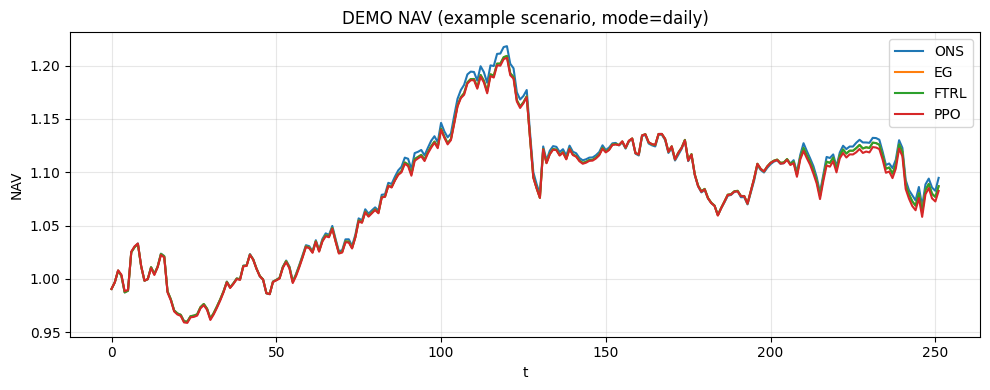

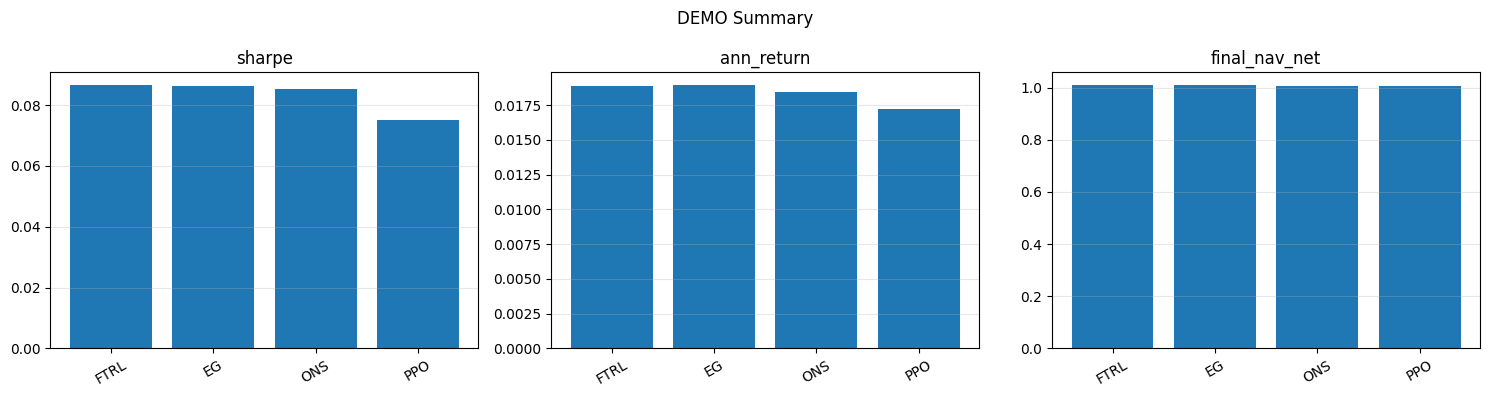

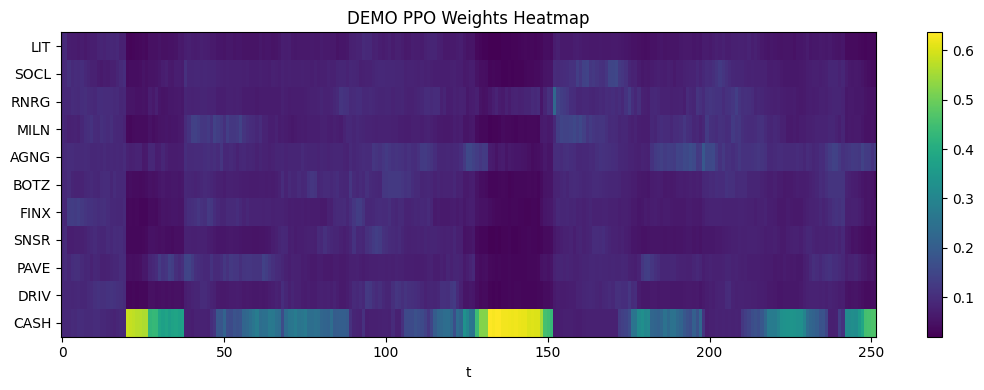

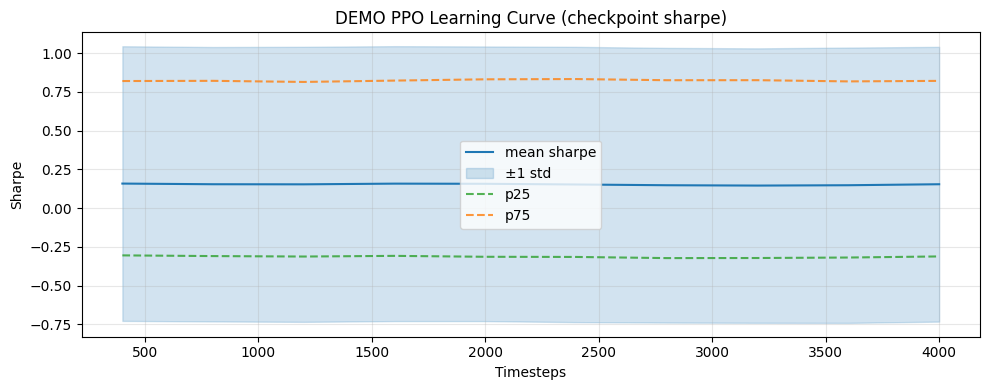

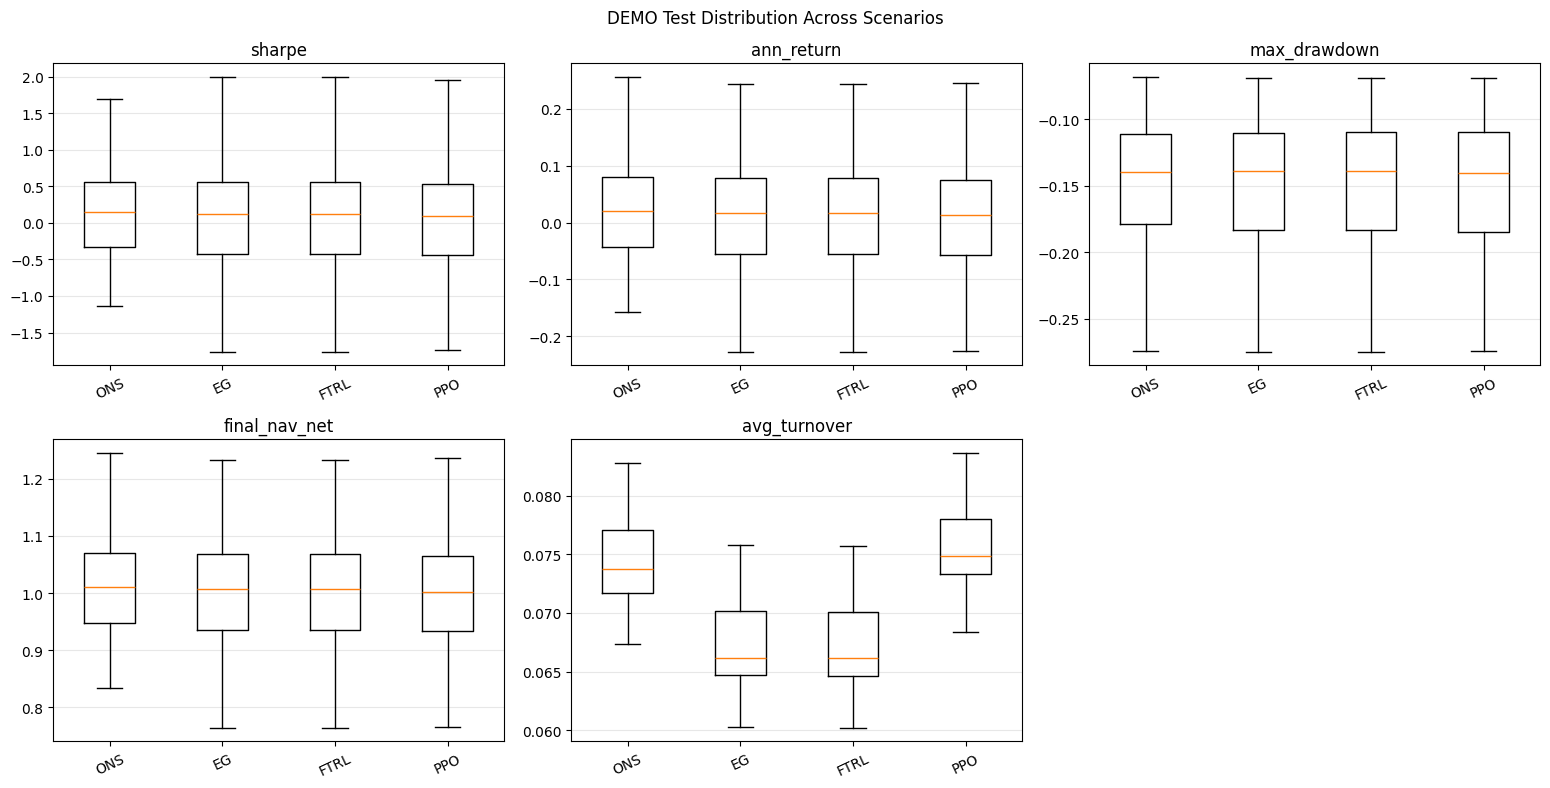

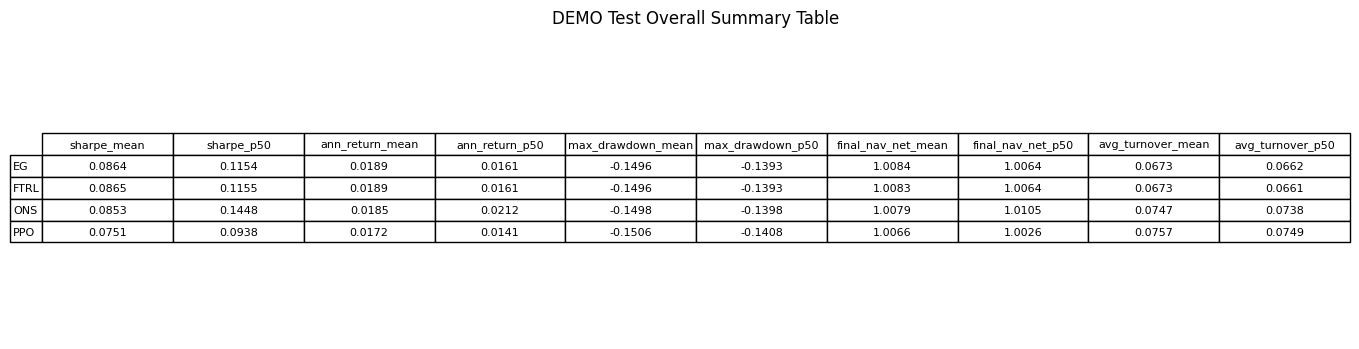

In [6]:
# ============================================================
# 10) 軽量デモ実行 (既定)
# ============================================================
DEMO_CFG = {
    "n_train": 30,
    "n_test": 30,
    "total_timesteps": 4_000,
    "train_seed": 123,
    "test_seed": 456,
    "horizon": 252,
    "block_len": 20,
    "rebalance_mode": "daily",
    "decision_weekday": 4,
    "execution_lag": 1,
    "learning_curve_points": 10,
    "curve_val_n_scenarios": 30,
    "curve_val_seed": 333,
    "curve_metric": "sharpe",
}

demo_res = run_experiment(**DEMO_CFG)

print("デモ実行 完了")
print("info:", demo_res["info"])
print(demo_res["summary"])


demo_figs = plot_experiment_results(demo_res, title_prefix="DEMO")


demo_learning_figs = plot_learning_and_test_summary(demo_res, title_prefix="DEMO")


In [7]:
# ============================================================
# 11) 本番実行 (1000 / 1000) : 明示的に有効化
# ============================================================
RUN_FULL = False

if RUN_FULL:
    FULL_CFG = {
        "n_train": 1000,
        "n_test": 1000,
        "total_timesteps": 200_000,
        "train_seed": 111,
        "test_seed": 222,
        "horizon": 252,
        "block_len": 20,
        "rebalance_mode": "daily",
        "decision_weekday": 4,
        "execution_lag": 1,
        "learning_curve_points": 10,
        "curve_val_n_scenarios": 30,
        "curve_val_seed": 333,
        "curve_metric": "sharpe",
    }
    full_res = run_experiment(**FULL_CFG)
    print("本番実行 完了")
    print("info:", full_res["info"])
    print(full_res["summary"])
    full_figs = plot_experiment_results(full_res, title_prefix="FULL")
    full_learning_figs = plot_learning_and_test_summary(full_res, title_prefix="FULL")
else:
    print("RUN_FULL=False のため本番実行をスキップしました。")


RUN_FULL=False のため本番実行をスキップしました。


## 使い方メモ

- 既定では軽量デモを日次リバランスで実行します。
- 本番（学習1000 / テスト1000）を実行する場合は `RUN_FULL = True` に変更して実行してください。
- 出力は参照実装互換の `weights / ret_net / nav_net / summary` などを維持しています。

- デモ/本番とも `plot_experiment_results(...)` で NAV・サマリ比較・PPOウェイトを可視化します。

- `plot_learning_and_test_summary(...)` で PPO 学習曲線とテスト全体サマリー（分布+集約表）を表示します。
- 学習/テスト後に `RUN_HISTORICAL=True` でヒストリカル評価（再学習なし推論）を実行できます。


## ヒストリカル実行 (学習/テスト後)\n
\n
人工データで学習したモデルを固定し、FIXED_TOP10 の全共通期間でヒストリカル評価を行います。\n

ヒストリカル共通期間: {'start': '2018-04-17', 'end': '2026-02-27', 'nobs': 1978, 'tickers': ['LIT', 'SOCL', 'RNRG', 'MILN', 'AGNG', 'BOTZ', 'FINX', 'SNSR', 'PAVE', 'DRIV']}
ヒストリカル実行メタ: {'rebalance_mode': 'daily', 'decision_weekday': 4, 'execution_lag': 1, 'ppo_num_timesteps_before': 10240, 'ppo_num_timesteps_after': 10240, 'start': '2018-04-17', 'end': '2026-02-27', 'nobs': 1978}

[HIST] Historical Summary
      ann_return  ann_vol   sharpe  max_drawdown  avg_turnover  total_cost  \
name                                                                         
ONS     0.074900 0.140900 0.513000     -0.265600      0.074800    0.029600   
PPO     0.069800 0.137500 0.490500     -0.273500      0.071700    0.028400   
FTRL    0.069600 0.137400 0.489800     -0.271200      0.067200    0.026600   
EG      0.069600 0.137500 0.489600     -0.271200      0.067300    0.026600   

      final_nav_net  final_nav_gross  nobs  
name                                        
ONS        1.630500         1.679500  197

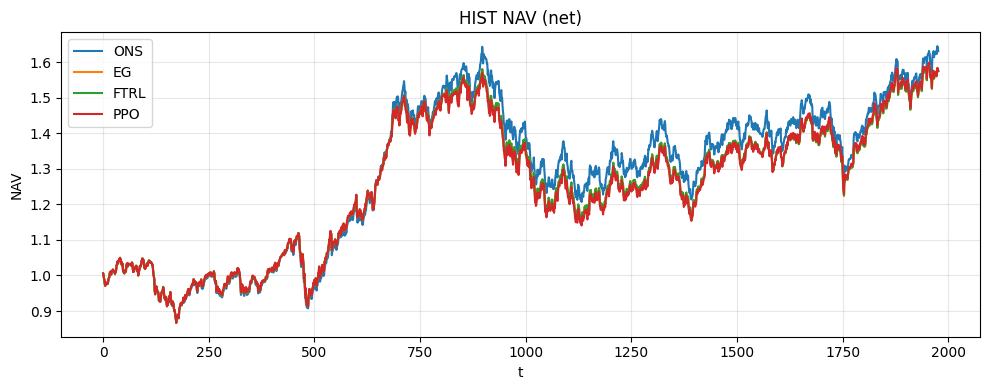

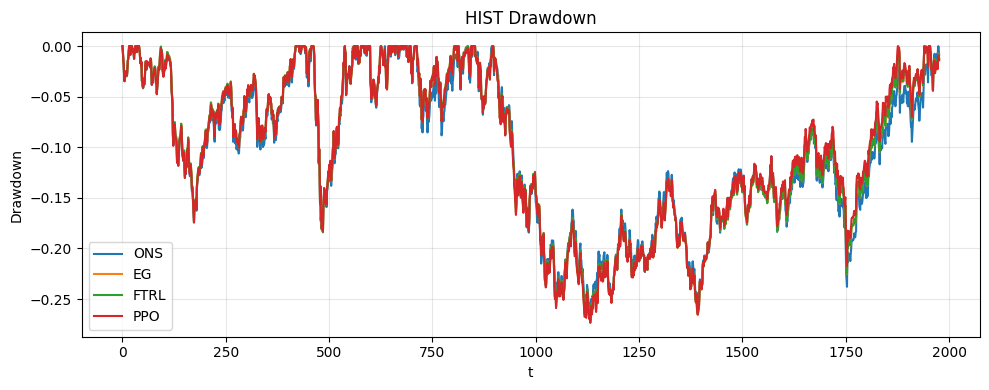

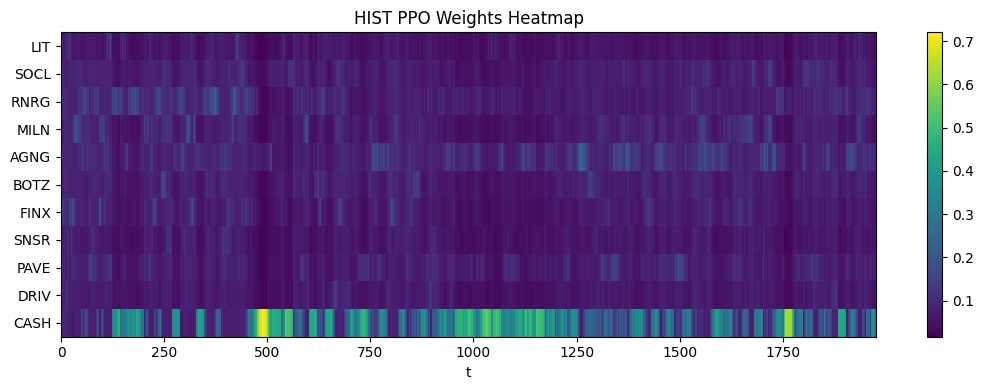

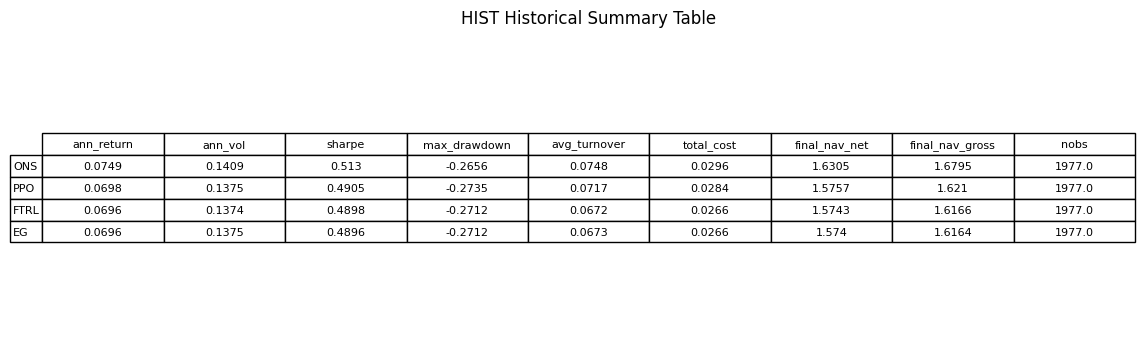

In [10]:
# ============================================================\n
# 12) ヒストリカル実行 (手動)\n
# ============================================================\n
RUN_HISTORICAL = True

if RUN_HISTORICAL:
    base_res = full_res if "full_res" in globals() else demo_res

    prices_hist, vix_hist, hist_panel_meta = load_historical_common_panel(
        theme_path=THEME_PATH,
        vix_path=VIX_PATH,
        tickers=FIXED_TOP10,
    )

    print("ヒストリカル共通期間:", hist_panel_meta)

    hist_res = run_historical_with_trained_model(
        experiment_res=base_res,
        prices_hist=prices_hist,
        vix_hist=vix_hist,
        rebalance_mode=None,
        decision_weekday=None,
        execution_lag=None,
        methods=("ONS", "EG", "FTRL", "PPO"),
    )

    print("ヒストリカル実行メタ:", hist_res["meta"])
    hist_figs = plot_historical_results(hist_res, title_prefix="HIST")
else:
    print("RUN_HISTORICAL=False のためヒストリカル実行をスキップしました。")